In [2]:
#mounting drive so i don't have to re-upload files, they're just there in my drive and that's connected
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#adding a folder for this project in my Google Drive
!mkdir /content/drive/MyDrive/celldrift

mkdir: cannot create directory ‘/content/drive/MyDrive/celldrift’: File exists


In [6]:
!pip install scanpy

In [1]:
import scanpy as sc
import pandas as pd

In [2]:
#downloading spleen dataset; 906 MB, also kidney dataset; 740 MB
#originally was using figshare, but it doesn't allow Colab script downloads
#as part of its firewall, so using the CELLxGENE webpage download link
!curl -L -o /content/drive/MyDrive/celldrift/mouse_data.h5ad "https://datasets.cellxgene.cziscience.com/be2af593-fb71-4c76-85a8-3c8400783c2a.h5ad"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2430M  100 2430M    0     0  71.7M      0  0:00:33  0:00:33 --:--:-- 71.8M


In [3]:
#changing h5ad file to AnnData, the type scanpy uses
adata = sc.read_h5ad('/content/drive/MyDrive/celldrift/mouse_data.h5ad')

In [14]:
#remember, .obs is still a pandas dataframe and you can do the usual pd operations with it
#"mask" because this line filters all the data that came in one file to just the information about the spleen

#.X cells as rows genes as columns. Expression data
#.obs facts about cells as columns, eg age, sex, origin tissue. No gene info, just describe rows of .X
#.var is one row per gene describing the columns of .X

#using .obs right now because that has the cell information which I can use to decide what groups I want to analyze
#from there, i do the actual data analysis on the .X

#mask isn't actually doing anything directly; that's just the true false filter you apply to adata to actually get the data; it's prework
spleen_mask = adata.obs['tissue'] == 'spleen'
#copying so that the original data isn't connected, and i can change it without affecting the original
spleen_data = adata[spleen_mask].copy()
#spleen_data.obs['cell_type'].value_counts()

['B cell', 'CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', 'proerythroblast', 'natural killer cell', 'granulocyte']
Categories (6, str): ['granulocyte', 'B cell', 'proerythroblast', 'natural killer cell',
                      'CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell']

In [5]:
#visualizing data distribution and saving it in csvs to my drive
per_age_cell_counts = pd.crosstab(spleen_data.obs['cell_type'], spleen_data.obs['age'])
per_age_cell_counts.to_csv('/content/drive/MyDrive/celldrift/celltype_by_age.csv')

per_donor_cell_counts = pd.crosstab(spleen_data.obs['cell_type'], spleen_data.obs['donor_id'])
per_donor_cell_counts.to_csv('/content/drive/MyDrive/celldrift/celltype_by_donor.csv')

per_age_donor_numbers = pd.crosstab(spleen_data.obs['age'], spleen_data.obs['donor_id'])
per_age_donor_numbers.to_csv('/content/drive/MyDrive/celldrift/age_by_donor.csv')

In [12]:
#taking original, raw data before TMS authors processed it; so before normalization, log-transformation, and scaling
#so processing is completely up to me, then saving the raw data to my drive
spleen_raw = spleen_data.raw.to_adata()
spleen_raw.write_h5ad('/content/drive/MyDrive/celldrift/spleen_raw.h5ad')

In [13]:
#normalizing the data; each cell was sequenced by a different method that determines how much of the gene
#shows up on measurement; this looks like some cells use some genes a lot more, but that's because the total
#number of genes is greater too. So, using scanpy to scale everything to a total of 10,000, and rework individual gene counts
#proportionately

#this modifies directly rather than creating a new object
sc.pp.normalize_total(spleen_raw, target_sum = 1e4)
print(spleen_raw.X[:5, :5])

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 6 stored elements and shape (5, 5)>
  Coords	Values
  (1, 0)	4.342793941497803
  (2, 0)	0.008843117393553257
  (2, 3)	0.061901818960905075
  (3, 0)	0.5403209328651428
  (3, 4)	4.534592151641846
  (4, 4)	3.617143154144287


In [28]:
#filtering to only bcells and only tcells
bcell_mask = spleen_raw.obs['cell_type'] == 'B cell'
bcell_data = spleen_raw[bcell_mask].copy()

tcell_mask = spleen_raw.obs['cell_type'].isin(['CD4-positive, alpha-beta T cell','CD8-positive, alpha-beta T cell' ])
tcell_data = spleen_raw[tcell_mask].copy()

In [29]:
#turns numbers into True/False; is the number of times this gene was expressed in this cell greater than zero or not,
#and this operation run across the whole matrix
bcell_detected = bcell_data.X > 0
#axis equals zero counts the number of cells each gene was found in
bcell_ncells_with_gene = bcell_detected.sum(axis=0)

#this was one row with a lot of columns; each column being a gene
#flattening that into one flat list so it's plottable
bcell_ncells_with_gene = bcell_ncells_with_gene.A1
print(bcell_ncells_with_gene)

#number of genes that are being reasonably expressed over the total number of cells
bcell_fraction = bcell_ncells_with_gene/bcell_detected.shape[0]

[1387    0   33 ...  156    1    0]


In [30]:
#repeating to get the same fraction for T cells
tcell_detected = tcell_data.X > 0

tcell_ncells_with_gene = tcell_detected.sum(axis=0)

tcell_ncells_with_gene = tcell_ncells_with_gene.A1
print(tcell_ncells_with_gene)

#number of genes that are being reasonably expressed over the total number of cells
tcell_fraction = tcell_ncells_with_gene/tcell_detected.shape[0]

[349   0   5 ...  31   0   1]


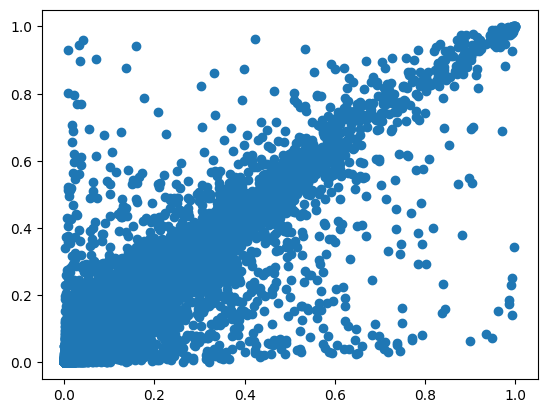

In [33]:
#now looking at the plot to see overlap between genes expressed a lot in bcells and genes expressed a lot in tcells
#turns out they differ quite a bit, so i'm going to take the genes most expressed separately in bcell and tcell,
#then get the intersection for my analysis
import matplotlib.pyplot as plt
plt.scatter(bcell_fraction, tcell_fraction)
plt.savefig('/content/drive/MyDrive/celldrift/bcell_vs_tcell_genes.png', dpi=150)
plt.show()

In [ ]:
#now filtering by genes; some gells are hard to detect by sequencing machines, and calculating coefficient of variation/CV for those
#doesn't measure actual gene expression, just measures sequencer capability. So, filtering to only genes that have